# Sprint 3 - US28 to US31

Regression Analysis for Transparency Assessment

---

# US28 — Correlação entre Rendimento Total e Tipos de Ativos por Cargo

**Descrição:**  
Como membro do Comité de Ética, quero perceber se o rendimento total declarado pelos agentes políticos está alinhado com os seus ativos totais declarados. Quero analisar se existe uma mudança significativa entre a primeira e última declaração dos agentes políticos. Para um dado cargo (role) fornecido como input, quero saber com que tipo de ativos (imóveis, veículos ou ações) o rendimento total declarado (salário bruto + rendimentos laterais) apresenta a correlação mais forte. Quero comparar os resultados usando a primeira e a última declaração. *(Aplica o coeficiente de correlação de Pearson.)*

---

## Conceitos Teóricos Aplicados

### Rendimento Total
O rendimento total de cada agente político é calculado como:

$$\text{total\_income} = \text{gross\_salary} + \text{side\_income\_consulting} + \text{side\_income\_board\_memberships}$$

### Ativos Totais
Os ativos declarados dividem-se em três categorias:
- $\text{assets\_in\_real\_estate}$ — imóveis;
- $\text{assets\_in\_vehicles}$ — veículos;
- $\text{assets\_in\_stocks}$ — ações.

### Coeficiente de Correlação Amostral de Pearson
O coeficiente de correlação amostral de Pearson, $r$, é uma medida da **direção** e **grau** com que duas variáveis se associam linearmente:

$$r = \frac{S_{xy}}{\sqrt{S_{xx} \times S_{yy}}}, \qquad -1 \leq r \leq 1$$

onde:
$$S_{xx} = \sum_{i=1}^{n}(x_i - \bar{x})^2, \quad S_{yy} = \sum_{i=1}^{n}(y_i - \bar{y})^2, \quad S_{xy} = \sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$$

### Coeficiente de Determinação
O coeficiente de determinação $r^2$ ($0 \leq r^2 \leq 1$) representa a proporção da variabilidade total de $y$ explicada pelo modelo linear.

### Interpretação do Coeficiente de Pearson

| Coeficiente de correlação | Correlação |
|---|---|
| $r = 1$ | perfeita positiva |
| $0.8 \leq r < 1$ | forte positiva |
| $0.5 \leq r < 0.8$ | moderada positiva |
| $0.1 \leq r < 0.5$ | fraca positiva |
| $0 < r < 0.1$ | ínfima positiva |
| $r = 0$ | nula |
| $-0.1 < r < 0$ | ínfima negativa |
| $-0.5 < r \leq -0.1$ | fraca negativa |
| $-0.8 < r \leq -0.5$ | moderada negativa |
| $-1 < r \leq -0.8$ | forte negativa |
| $r = -1$ | perfeita negativa |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ── Carregamento e limpeza ──────────────────────────────────────────────────
df = pd.read_csv('../Dados/Regression_dataset1_declarations.csv')
df.columns = df.columns.str.strip()
df['declaration_date'] = pd.to_datetime(df['declaration_date'])

# ── Cálculo do Rendimento Total ─────────────────────────────────────────────
# total_income = salário bruto + rendimentos de consultoria + rendimentos de memberships
df['total_income'] = (
    df['gross_salary'] +
    df['side_income_consulting'] +
    df['side_income_board_memberships']
)

# ── INPUT: Role a analisar ───────────────────────────────────────────────────
ROLE_INPUT = 'MP'   # <- alterar aqui para o cargo pretendido

roles_disponiveis = sorted(df['role'].unique())
print(f"Roles disponíveis: {roles_disponiveis}")
print(f"Dataset carregado: {df.shape[0]} declarações, {df['agent_id'].nunique()} agentes únicos")
print(f"\nRole selecionado: '{ROLE_INPUT}'")

if ROLE_INPUT not in roles_disponiveis:
    raise ValueError(f"Role '{ROLE_INPUT}' não encontrado. Opções disponíveis: {roles_disponiveis}")

Roles disponíveis: ['Advisor', 'Judge', 'MP', 'Minister', 'State Secretary']
Dataset carregado: 4840 declarações, 828 agentes únicos

Role selecionado: 'MP'


## 1. Seleção da Primeira e Última Declaração por Agente

Para cada agente político com o cargo selecionado, identificamos:
- **Primeira declaração:** a observação com a data mais antiga;
- **Última declaração:** a observação com a data mais recente.

In [2]:
# ── Filtrar pelo role selecionado ────────────────────────────────────────────
df_role = df[df['role'] == ROLE_INPUT].copy()

# ── Primeira declaração de cada agente ──────────────────────────────────────
# (linha com a data mais antiga por agente)
idx_first = df_role.groupby('agent_id')['declaration_date'].idxmin()
df_first  = df_role.loc[idx_first].reset_index(drop=True)

# ── Última declaração de cada agente ────────────────────────────────────────
# (linha com a data mais recente por agente)
idx_last  = df_role.groupby('agent_id')['declaration_date'].idxmax()
df_last   = df_role.loc[idx_last].reset_index(drop=True)

# ── Agentes com pelo menos duas declarações distintas ───────────────────────
# (para que a comparação primeira vs. última seja significativa)
agentes_multi = df_role.groupby('agent_id').filter(lambda g: g['declaration_date'].nunique() > 1)['agent_id'].unique()

print(f"Agentes com o role '{ROLE_INPUT}': {df_role['agent_id'].nunique()}")
print(f"  › com mais de uma declaração (data distinta): {len(agentes_multi)}")
print(f"\nPrimeiras declarações — {len(df_first)} linhas")
print(f"Últimas  declarações  — {len(df_last)} linhas")

Agentes com o role 'MP': 212
  › com mais de uma declaração (data distinta): 212

Primeiras declarações — 212 linhas
Últimas  declarações  — 212 linhas


## 2. Cálculo do Coeficiente de Pearson

Para cada tipo de ativo calculamos $r$ entre o rendimento total e o valor do ativo, usando:
- o subconjunto das **primeiras** declarações;
- o subconjunto das **últimas** declarações.

In [3]:
# ── Tipos de ativos a analisar ───────────────────────────────────────────────
ATIVOS = {
    'assets_in_real_estate': 'Imóveis',
    'assets_in_vehicles':    'Veículos',
    'assets_in_stocks':      'Ações',
}

def interpreta_pearson(r):
    """Retorna a classificação qualitativa do coeficiente de Pearson."""
    abs_r = abs(r)
    sinal = 'positiva' if r >= 0 else 'negativa'
    if abs_r == 1:   return f'perfeita {sinal}'
    if abs_r >= 0.8: return f'forte {sinal}'
    if abs_r >= 0.5: return f'moderada {sinal}'
    if abs_r >= 0.1: return f'fraca {sinal}'
    if abs_r > 0:    return f'ínfima {sinal}'
    return 'nula'

def calcula_pearson_manual(x_series, y_series):
    """Calcula o coeficiente de Pearson manualmente, usando Sxx, Syy, Sxy."""
    x = x_series.values
    y = y_series.values
    n = len(x)
    x_bar = x.mean()
    y_bar = y.mean()
    Sxx = np.sum((x - x_bar) ** 2)
    Syy = np.sum((y - y_bar) ** 2)
    Sxy = np.sum((x - x_bar) * (y - y_bar))
    if Sxx == 0 or Syy == 0:
        return np.nan, np.nan
    r = Sxy / np.sqrt(Sxx * Syy)
    return r, r ** 2

# ── Calcular Pearson para cada ativo, em ambos os subconjuntos ───────────────
resultados = []

for col_ativo, nome_ativo in ATIVOS.items():
    for label, df_sub in [('Primeira declaração', df_first), ('Última declaração', df_last)]:
        r, r2 = calcula_pearson_manual(df_sub['total_income'], df_sub[col_ativo])
        # valor-p via scipy (para referência)
        _, p_val = stats.pearsonr(df_sub['total_income'], df_sub[col_ativo])
        resultados.append({
            'Declaração':    label,
            'Tipo de Ativo': nome_ativo,
            'r':             round(r,  4),
            'r²':            round(r2, 4),
            'p-value':       round(p_val, 4),
            'Classificação': interpreta_pearson(r),
        })

df_res = pd.DataFrame(resultados)

# ── Apresentar tabela ────────────────────────────────────────────────────────
print('=' * 90)
print(f"COEFICIENTES DE PEARSON — RENDIMENTO TOTAL vs. ATIVOS — Role: {ROLE_INPUT}")
print('=' * 90)
print(df_res.to_string(index=False))

COEFICIENTES DE PEARSON — RENDIMENTO TOTAL vs. ATIVOS — Role: MP
         Declaração Tipo de Ativo       r     r²  p-value   Classificação
Primeira declaração       Imóveis  0.0672 0.0045   0.3300 ínfima positiva
  Última declaração       Imóveis  0.0369 0.0014   0.5934 ínfima positiva
Primeira declaração      Veículos -0.0137 0.0002   0.8433 ínfima negativa
  Última declaração      Veículos  0.0411 0.0017   0.5515 ínfima positiva
Primeira declaração         Ações -0.0383 0.0015   0.5791 ínfima negativa
  Última declaração         Ações  0.8571 0.7346   0.0000  forte positiva


## 3. Visualização: Gráficos de Dispersão com Reta de Regressão

Para cada tipo de ativo e para cada subconjunto (primeira vs. última declaração), traçamos o diagrama de dispersão com a reta de regressão estimada, de forma a visualizar a força e a direção da relação linear.

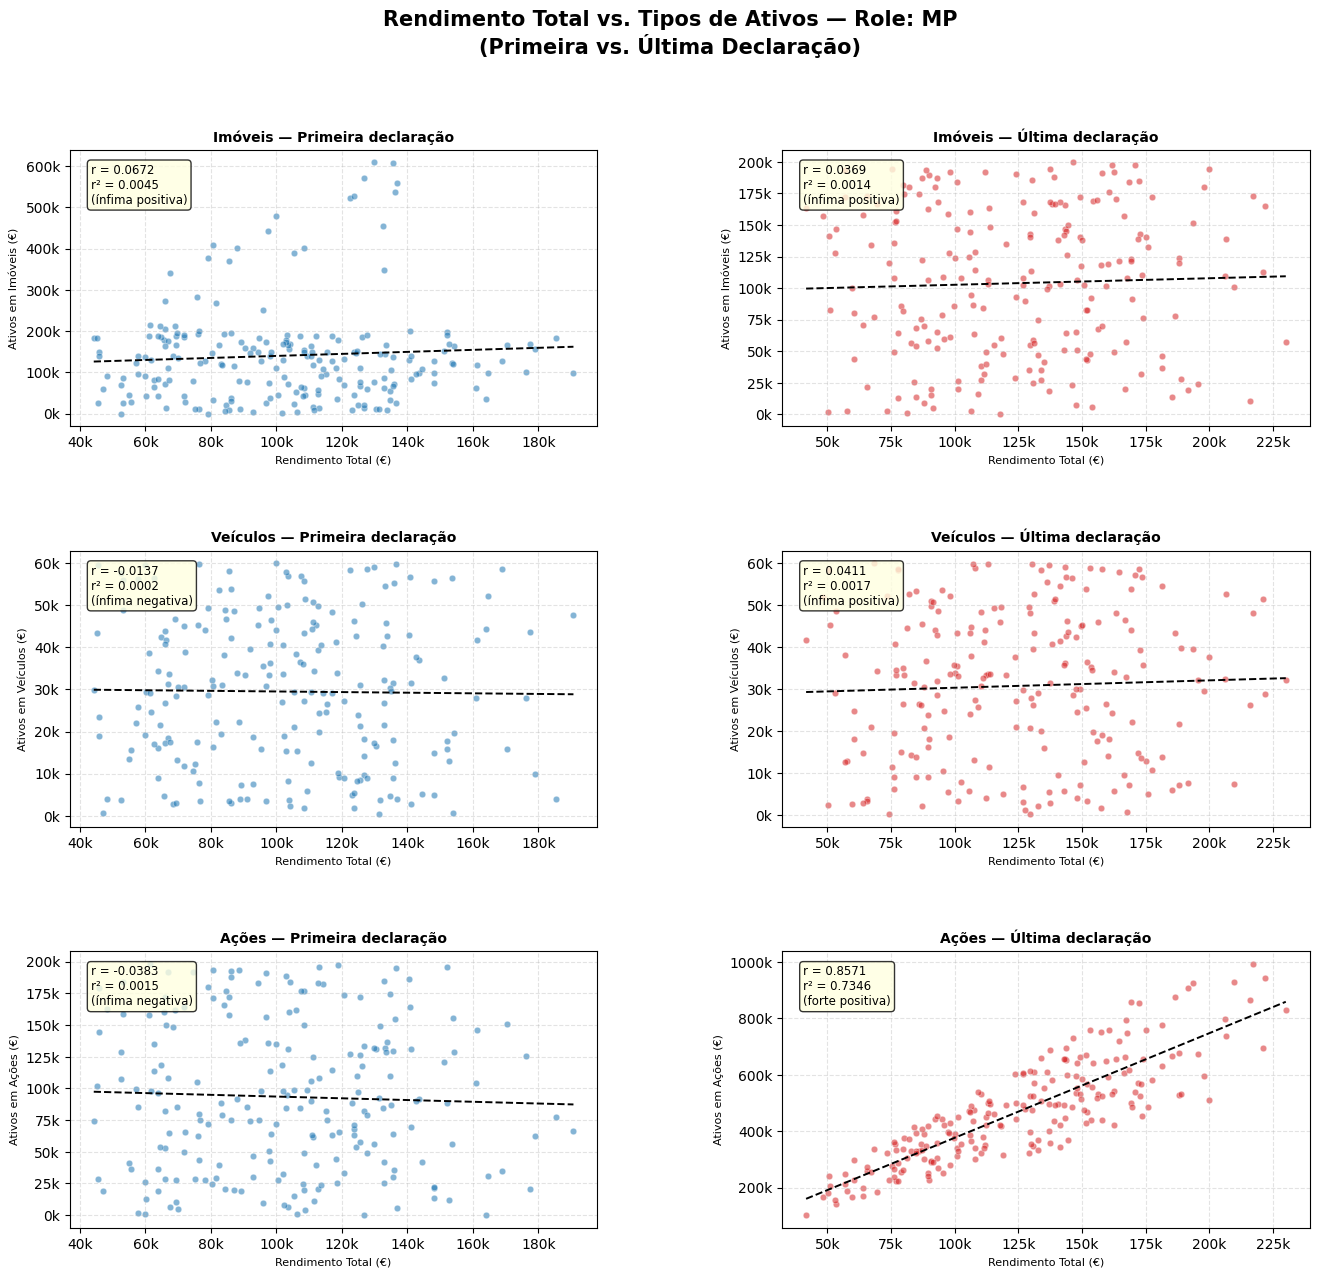

Gráfico guardado em: US28_dispersao_rendimento_ativos.svg


In [4]:
# ── Configuração da grelha de gráficos ──────────────────────────────────────
# 3 ativos × 2 subconjuntos = 6 gráficos em grelha 3×2
fig = plt.figure(figsize=(16, 14))
fig.suptitle(
    f'Rendimento Total vs. Tipos de Ativos — Role: {ROLE_INPUT}\n'
    f'(Primeira vs. Última Declaração)',
    fontsize=15, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

cores = {'Primeira declaração': '#1f77b4', 'Última declaração': '#d62728'}

for row_idx, (col_ativo, nome_ativo) in enumerate(ATIVOS.items()):
    for col_idx, (label, df_sub) in enumerate(
        [('Primeira declaração', df_first), ('Última declaração', df_last)]
    ):
        ax = fig.add_subplot(gs[row_idx, col_idx])

        x = df_sub['total_income']
        y = df_sub[col_ativo]
        r, r2 = calcula_pearson_manual(x, y)

        # Dispersão
        ax.scatter(x, y, alpha=0.55, s=22, color=cores[label], edgecolors='white', linewidths=0.4)

        # Reta de regressão
        m, b, *_ = stats.linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_line, m * x_line + b, color='black', linewidth=1.4, linestyle='--')

        # Anotação r e r²
        ax.annotate(
            f'r = {r:.4f}\nr² = {r2:.4f}\n({interpreta_pearson(r)})',
            xy=(0.04, 0.95), xycoords='axes fraction',
            fontsize=8.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
        )

        ax.set_title(f'{nome_ativo} — {label}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Rendimento Total (€)', fontsize=8)
        ax.set_ylabel(f'Ativos em {nome_ativo} (€)', fontsize=8)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
        ax.grid(axis='both', linestyle='--', alpha=0.35)

plt.savefig('US28_dispersao_rendimento_ativos.svg', format='svg', bbox_inches='tight')
plt.show()
print('Gráfico guardado em: US28_dispersao_rendimento_ativos.svg')

## 4. Comparação Direta: Primeira vs. Última Declaração

O gráfico de barras seguinte facilita a comparação visual do coeficiente $r$ entre subconjuntos e tipos de ativo.

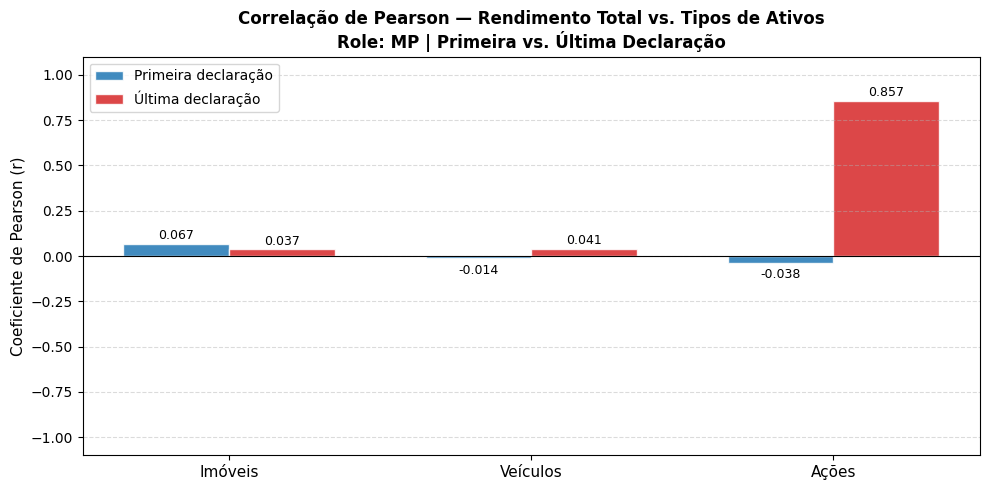

Gráfico guardado em: US28_barras_pearson_comparativo.svg


In [5]:
# ── Gráfico de barras comparativo ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

nomes_ativos = list(ATIVOS.values())        # ['Imóveis', 'Veículos', 'Ações']
x_pos = np.arange(len(nomes_ativos))
largura = 0.35

r_first = [
    df_res[(df_res['Declaração'] == 'Primeira declaração') & (df_res['Tipo de Ativo'] == n)]['r'].values[0]
    for n in nomes_ativos
]
r_last = [
    df_res[(df_res['Declaração'] == 'Última declaração')   & (df_res['Tipo de Ativo'] == n)]['r'].values[0]
    for n in nomes_ativos
]

bars1 = ax.bar(x_pos - largura/2, r_first, largura, label='Primeira declaração',
               color='#1f77b4', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x_pos + largura/2, r_last,  largura, label='Última declaração',
               color='#d62728', alpha=0.85, edgecolor='white')

# Anotar valor r em cada barra
for bar in bars1 + bars2:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + (0.01 if h >= 0 else -0.03),
        f'{h:.3f}',
        ha='center', va='bottom' if h >= 0 else 'top',
        fontsize=9
    )

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(nomes_ativos, fontsize=11)
ax.set_ylabel('Coeficiente de Pearson (r)', fontsize=11)
ax.set_title(
    f'Correlação de Pearson — Rendimento Total vs. Tipos de Ativos\n'
    f'Role: {ROLE_INPUT} | Primeira vs. Última Declaração',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.45)

plt.tight_layout()
plt.savefig('US28_barras_pearson_comparativo.svg', format='svg', bbox_inches='tight')
plt.show()
print('Gráfico guardado em: US28_barras_pearson_comparativo.svg')

## 5. Interpretação dos Resultados

In [6]:
# ── Identificar ativo com maior |r| em cada subconjunto ─────────────────────
def ativo_mais_correlacionado(label):
    sub = df_res[df_res['Declaração'] == label].copy()
    sub['|r|'] = sub['r'].abs()
    melhor = sub.loc[sub['|r|'].idxmax()]
    return melhor

melhor_first = ativo_mais_correlacionado('Primeira declaração')
melhor_last  = ativo_mais_correlacionado('Última declaração')

print('=' * 90)
print(f"INTERPRETAÇÃO DOS RESULTADOS — Role: {ROLE_INPUT}")
print('=' * 90)

print(f"""
PRIMEIRA DECLARAÇÃO
  › Ativo com correlação mais forte: {melhor_first['Tipo de Ativo']}
    r = {melhor_first['r']:.4f}  ({melhor_first['Classificação']})
    r² = {melhor_first['r²']:.4f}  → o rendimento total explica {melhor_first['r²']*100:.1f}% da variabilidade dos {melhor_first['Tipo de Ativo'].lower()}
""")

print(f"""ÚLTIMA DECLARAÇÃO
  › Ativo com correlação mais forte: {melhor_last['Tipo de Ativo']}
    r = {melhor_last['r']:.4f}  ({melhor_last['Classificação']})
    r² = {melhor_last['r²']:.4f}  → o rendimento total explica {melhor_last['r²']*100:.1f}% da variabilidade dos {melhor_last['Tipo de Ativo'].lower()}
""")

# ── Variação entre primeira e última ────────────────────────────────────────
print("MUDANÇA DA PRIMEIRA PARA A ÚLTIMA DECLARAÇÃO")
print('-' * 60)
for nome_ativo in nomes_ativos:
    r_f = df_res[(df_res['Declaração'] == 'Primeira declaração') & (df_res['Tipo de Ativo'] == nome_ativo)]['r'].values[0]
    r_l = df_res[(df_res['Declaração'] == 'Última declaração')   & (df_res['Tipo de Ativo'] == nome_ativo)]['r'].values[0]
    delta = r_l - r_f
    sentido = 'aumentou' if delta > 0 else 'diminuiu'
    print(f"  {nome_ativo:<12}: r={r_f:.4f} → r={r_l:.4f}  (Δ={delta:+.4f}, {sentido})")

print()
if melhor_first['Tipo de Ativo'] == melhor_last['Tipo de Ativo']:
    print(f"→ O tipo de ativo com correlação mais forte manteve-se: {melhor_last['Tipo de Ativo']}")
else:
    print(f"→ Houve mudança no tipo de ativo com correlação mais forte:")
    print(f"  Primeira declaração: {melhor_first['Tipo de Ativo']} | Última declaração: {melhor_last['Tipo de Ativo']}")

INTERPRETAÇÃO DOS RESULTADOS — Role: MP

PRIMEIRA DECLARAÇÃO
  › Ativo com correlação mais forte: Imóveis
    r = 0.0672  (ínfima positiva)
    r² = 0.0045  → o rendimento total explica 0.4% da variabilidade dos imóveis

ÚLTIMA DECLARAÇÃO
  › Ativo com correlação mais forte: Ações
    r = 0.8571  (forte positiva)
    r² = 0.7346  → o rendimento total explica 73.5% da variabilidade dos ações

MUDANÇA DA PRIMEIRA PARA A ÚLTIMA DECLARAÇÃO
------------------------------------------------------------
  Imóveis     : r=0.0672 → r=0.0369  (Δ=-0.0303, diminuiu)
  Veículos    : r=-0.0137 → r=0.0411  (Δ=+0.0548, aumentou)
  Ações       : r=-0.0383 → r=0.8571  (Δ=+0.8954, aumentou)

→ Houve mudança no tipo de ativo com correlação mais forte:
  Primeira declaração: Imóveis | Última declaração: Ações


# US29 — Deteção de Acumulação de Riqueza Anormal

**Descrição:**  
Como membro do Comité de Ética, o meu objetivo é detetar acumulações de riqueza invulgares. Para tal, pretendo estabelecer um *benchmark* que relacione os ativos e o rendimento, de forma a identificar casos anormais. Quero saber qual é a relação esperada entre o total de fontes de rendimento (salário e rendimento extra) e o total de ativos declarados (imóveis, veículos e ações). Identificar os 10 agentes que apresentam o maior desvio face a esse padrão esperado, indicando uma potencial acumulação de riqueza inexplicável. É possível identificar agentes cujos desvios possam ser considerados *outliers*? Para cada agente, considera-se apenas a declaração mais recente.

---

## Conceitos Teóricos Aplicados

### Variáveis

$$\text{total\_income} = \text{gross\_salary} + \text{side\_income\_consulting} + \text{side\_income\_board\_memberships}$$

$$\text{total\_assets} = \text{assets\_in\_real\_estate} + \text{assets\_in\_vehicles} + \text{assets\_in\_stocks}$$

### Reta de Regressão (*Benchmark*)
Estimada pelo método dos mínimos quadrados:

$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x, \qquad \hat{\beta}_1 = \frac{S_{xy}}{S_{xx}}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

### Resíduos
Para cada agente $i$, o resíduo representa o desvio entre o valor observado e o valor esperado pelo modelo:

$$\hat{e}_i = y_i - \hat{y}_i$$

Um resíduo **positivo** indica ativos superiores ao esperado para o rendimento declarado — potencial acumulação inexplicável.  
Um resíduo **negativo** indica ativos inferiores ao esperado.

### Deteção de Outliers — Método IQR
Os limites para deteção de outliers nos resíduos são:

$$\text{Limite inferior} = Q_1 - 1.5 \times IQR$$
$$\text{Limite superior} = Q_3 + 1.5 \times IQR$$

onde $IQR = Q_3 - Q_1$. Resíduos fora destes limites são considerados *outliers*.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ── Carregamento e limpeza ──────────────────────────────────────────────────
df = pd.read_csv('../Dados/Regression_dataset1_declarations.csv')
df.columns = df.columns.str.strip()
df['declaration_date'] = pd.to_datetime(df['declaration_date'])

# ── Cálculo das variáveis agregadas ────────────────────────────────────────
df['total_income'] = (
    df['gross_salary'] +
    df['side_income_consulting'] +
    df['side_income_board_memberships']
)
df['total_assets'] = (
    df['assets_in_real_estate'] +
    df['assets_in_vehicles'] +
    df['assets_in_stocks']
)

print(f"Dataset carregado: {df.shape[0]} declarações, {df['agent_id'].nunique()} agentes únicos")

Dataset carregado: 4840 declarações, 828 agentes únicos


## 1. Seleção da Declaração Mais Recente por Agente

Para cada agente político, considera-se apenas a declaração com a data mais recente.

In [8]:
# ── Declaração mais recente por agente ─────────────────────────────────────
idx_last = df.groupby('agent_id')['declaration_date'].idxmax()
df_last  = df.loc[idx_last].reset_index(drop=True)

print(f"Agentes considerados (declaração mais recente): {len(df_last)}")
print(f"\nEstatísticas descritivas:")
print(df_last[['total_income', 'total_assets']].describe().round(2).to_string())

Agentes considerados (declaração mais recente): 828

Estatísticas descritivas:
       total_income  total_assets
count        828.00        828.00
mean      125024.15     603921.65
std        41635.58     198086.19
min        41637.77     160578.02
25%        90653.94     458520.36
50%       123932.40     583215.95
75%       154440.11     729351.12
max       230093.31    1290302.44


## 2. Estimação do *Benchmark* — Reta de Regressão

Estimamos a reta de regressão que relaciona o rendimento total (variável independente $x$) com o total de ativos declarados (variável dependente $y$). Esta reta constitui o *benchmark* — o padrão esperado para um agente com um dado nível de rendimento.

In [9]:
x = df_last['total_income']
y = df_last['total_assets']

# ── Mínimos quadrados manual ────────────────────────────────────────────────
x_bar = x.mean()
y_bar = y.mean()
Sxx = np.sum((x - x_bar) ** 2)
Syy = np.sum((y - y_bar) ** 2)
Sxy = np.sum((x - x_bar) * (y - y_bar))

beta1 = Sxy / Sxx
beta0 = y_bar - beta1 * x_bar

sqe = Syy - (Sxy ** 2) / Sxx
s2  = sqe / (len(x) - 2)
r   = Sxy / np.sqrt(Sxx * Syy)
r2  = r ** 2

print('=' * 65)
print('BENCHMARK — RETA DE REGRESSÃO: total_assets = β₀ + β₁ × total_income')
print('=' * 65)
print(f"  β̂₀ (intercepto) = {beta0:,.2f} €")
print(f"  β̂₁ (declive)    = {beta1:.4f}")
print(f"  Reta: total_assets = {beta0:,.2f} + {beta1:.4f} × total_income")
print(f"\n  r   = {r:.4f}")
print(f"  r²  = {r2:.4f}  → o rendimento total explica {r2*100:.1f}% da variabilidade dos ativos")
print(f"  sqe = {sqe:,.2f}")
print(f"  s²  = {s2:,.2f}")

BENCHMARK — RETA DE REGRESSÃO: total_assets = β₀ + β₁ × total_income
  β̂₀ (intercepto) = 121,836.21 €
  β̂₁ (declive)    = 3.8559
  Reta: total_assets = 121,836.21 + 3.8559 × total_income

  r   = 0.8105
  r²  = 0.6569  → o rendimento total explica 65.7% da variabilidade dos ativos
  sqe = 11,134,466,986,273.75
  s²  = 13,479,984,244.88


## 3. Cálculo dos Resíduos e Identificação dos Top 10 Desvios

Para cada agente, calculamos o resíduo $\hat{e}_i = y_i - \hat{y}_i$. Os 10 agentes com maior desvio em valor absoluto são aqueles cujos ativos mais se afastam — para cima ou para baixo — do padrão esperado pelo modelo.

In [10]:
# ── Calcular resíduos ───────────────────────────────────────────────────────
df_last = df_last.copy()
df_last['y_hat']   = beta0 + beta1 * df_last['total_income']
df_last['residuo'] = df_last['total_assets'] - df_last['y_hat']
df_last['|residuo|'] = df_last['residuo'].abs()

# ── Top 10 maiores desvios ──────────────────────────────────────────────────
top10 = (
    df_last
    .nlargest(10, '|residuo|')
    [['agent_id', 'role', 'declaration_date', 'total_income', 'total_assets', 'y_hat', 'residuo']]
    .reset_index(drop=True)
)
top10.index += 1

# Formatar para apresentação
top10_display = top10.copy()
for col in ['total_income', 'total_assets', 'y_hat', 'residuo']:
    top10_display[col] = top10_display[col].map(lambda v: f'{v:,.2f} €')
top10_display['declaration_date'] = top10_display['declaration_date'].dt.strftime('%Y-%m-%d')

print('=' * 100)
print('TOP 10 AGENTES COM MAIOR DESVIO FACE AO BENCHMARK')
print('=' * 100)
print(top10_display.rename(columns={
    'agent_id':         'Agente',
    'role':             'Cargo',
    'declaration_date': 'Data',
    'total_income':     'Rendimento Total',
    'total_assets':     'Ativos Totais',
    'y_hat':            'Ativos Esperados (ŷ)',
    'residuo':          'Resíduo (desvio)',
}).to_string())
print()
print("Nota: resíduo positivo → ativos superiores ao esperado (acumulação potencialmente inexplicável)")
print("      resíduo negativo → ativos inferiores ao esperado")

TOP 10 AGENTES COM MAIOR DESVIO FACE AO BENCHMARK
   Agente     Cargo        Data Rendimento Total   Ativos Totais Ativos Esperados (ŷ) Resíduo (desvio)
1   A0365     Judge  2025-10-20     198,118.78 €    526,333.87 €         885,770.07 €    -359,436.20 €
2   A0581   Advisor  2024-11-26     210,537.06 €  1,290,302.44 €         933,654.20 €     356,648.24 €
3   A0119        MP  2025-10-31     172,482.72 €  1,098,668.19 €         786,919.00 €     311,749.19 €
4   A0245  Minister  2024-05-14     163,821.12 €    452,919.53 €         753,520.40 €    -300,600.87 €
5   A0667   Advisor  2023-08-26     132,805.33 €    932,781.62 €         633,925.41 €     298,856.21 €
6   A0232  Minister  2024-06-16     114,422.09 €    861,432.93 €         563,040.77 €     298,392.16 €
7   A0342     Judge  2024-06-09     193,033.95 €  1,161,999.72 €         866,163.28 €     295,836.44 €
8   A0393     Judge  2024-01-09     163,285.05 €    470,095.83 €         751,453.35 €    -281,357.52 €
9   A0739   Advisor  20

## 4. Deteção de Outliers nos Resíduos — Método IQR

Aplicamos o método IQR aos resíduos de todos os agentes para determinar quais podem ser considerados *outliers* estatísticos.

In [11]:
# ── Método IQR nos resíduos ─────────────────────────────────────────────────
Q1  = df_last['residuo'].quantile(0.25)
Q3  = df_last['residuo'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

df_last['outlier'] = (df_last['residuo'] < lim_inf) | (df_last['residuo'] > lim_sup)
df_outliers = df_last[df_last['outlier']].sort_values('residuo', ascending=False)

print('=' * 65)
print('DETEÇÃO DE OUTLIERS — MÉTODO IQR')
print('=' * 65)
print(f"  Q1             = {Q1:,.2f} €")
print(f"  Q3             = {Q3:,.2f} €")
print(f"  IQR            = {IQR:,.2f} €")
print(f"  Limite inferior = Q1 - 1.5×IQR = {lim_inf:,.2f} €")
print(f"  Limite superior = Q3 + 1.5×IQR = {lim_sup:,.2f} €")
print(f"\n  Outliers detetados: {len(df_outliers)} agente(s)")

if len(df_outliers) > 0:
    print()
    out_display = df_outliers[['agent_id', 'role', 'total_income', 'total_assets', 'residuo']].copy()
    for col in ['total_income', 'total_assets', 'residuo']:
        out_display[col] = out_display[col].map(lambda v: f'{v:,.2f} €')
    print(out_display.rename(columns={
        'agent_id':     'Agente',
        'role':         'Cargo',
        'total_income': 'Rendimento Total',
        'total_assets': 'Ativos Totais',
        'residuo':      'Resíduo',
    }).to_string(index=False))
else:
    print("  Nenhum agente apresenta um resíduo considerado outlier pelo método IQR.")

DETEÇÃO DE OUTLIERS — MÉTODO IQR
  Q1             = -82,576.54 €
  Q3             = 78,852.98 €
  IQR            = 161,429.52 €
  Limite inferior = Q1 - 1.5×IQR = -324,720.82 €
  Limite superior = Q3 + 1.5×IQR = 320,997.26 €

  Outliers detetados: 2 agente(s)

Agente   Cargo Rendimento Total  Ativos Totais       Resíduo
 A0581 Advisor     210,537.06 € 1,290,302.44 €  356,648.24 €
 A0365   Judge     198,118.78 €   526,333.87 € -359,436.20 €


## 5. Visualização

Três gráficos complementares:
- **Dispersão com benchmark** — reta de regressão e destaque dos top 10 e outliers;
- **Gráfico de barras dos resíduos** — top 10 desvios com limites IQR;
- **Boxplot dos resíduos** — distribuição e outliers.

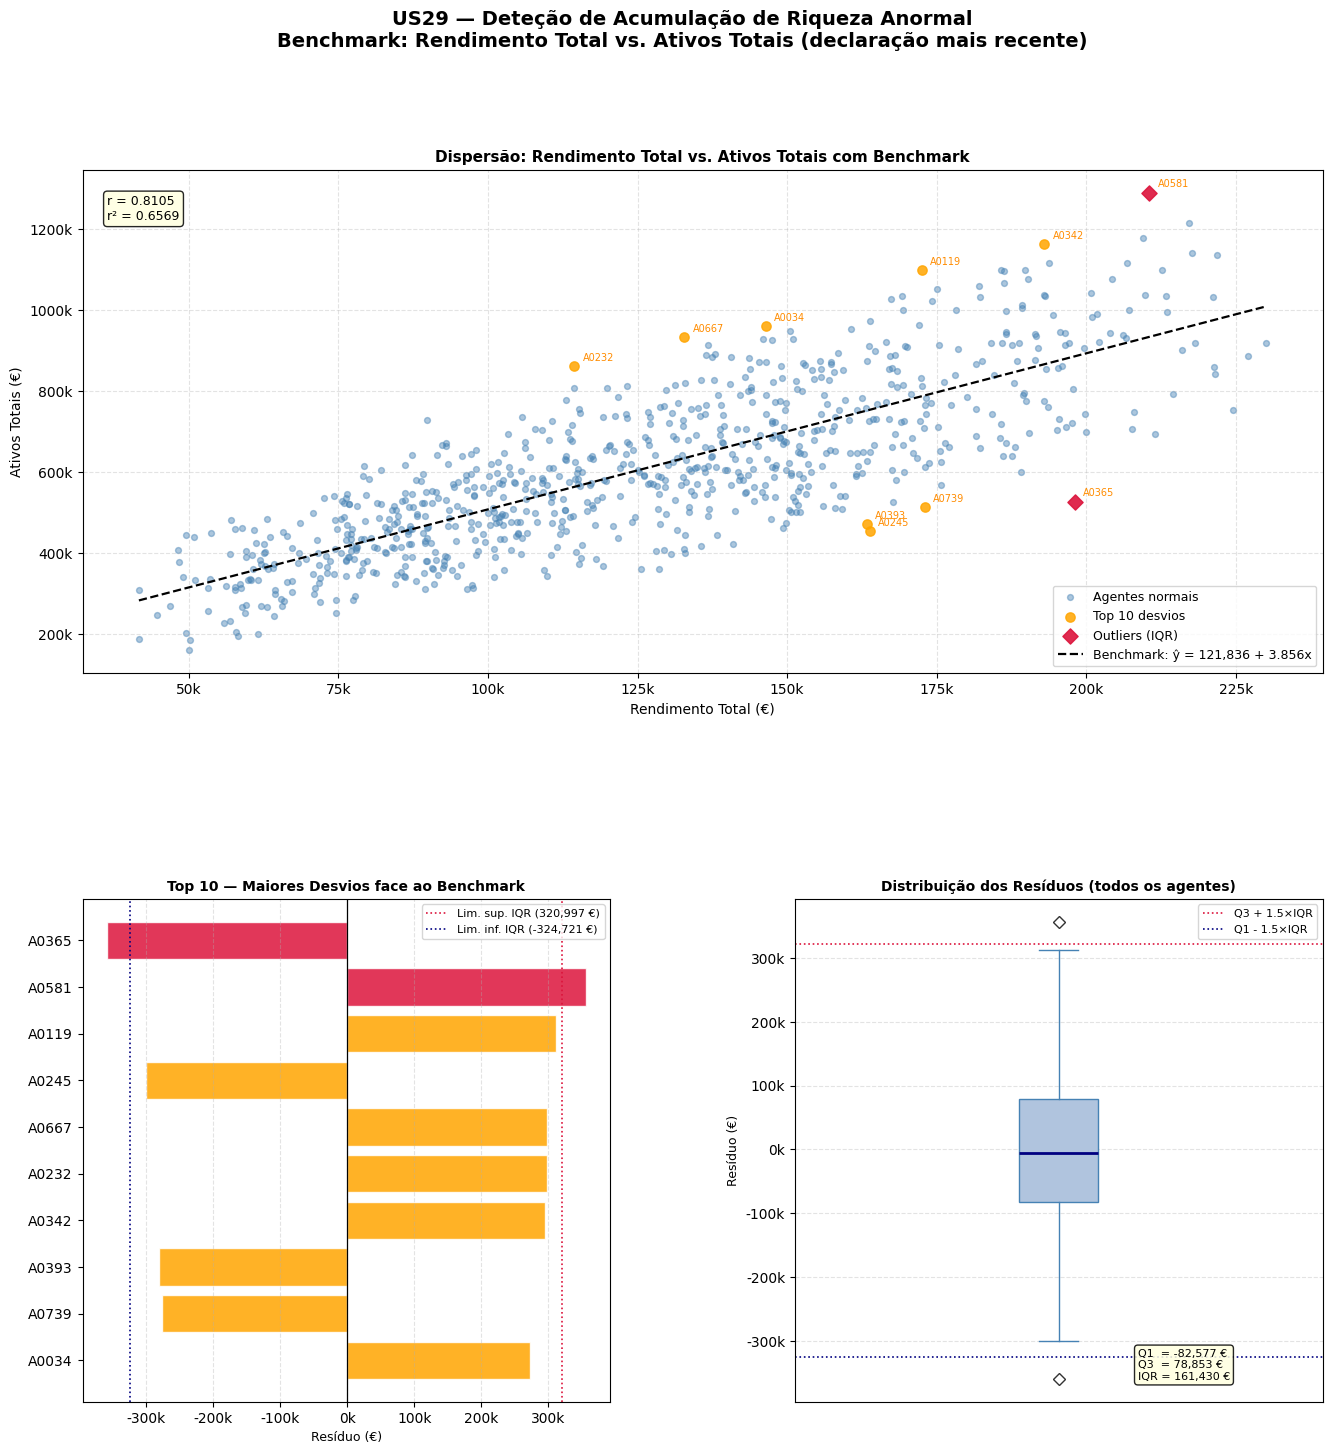

Gráfico guardado em: US29_benchmark_desvios.svg


In [12]:
fig = plt.figure(figsize=(16, 16))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle(
    'US29 — Deteção de Acumulação de Riqueza Anormal\n'
    'Benchmark: Rendimento Total vs. Ativos Totais (declaração mais recente)',
    fontsize=14, fontweight='bold', y=0.98
)

# ── Gráfico 1: Dispersão com reta de regressão ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :])

# Pontos normais
mask_normal  = ~df_last['outlier'] & ~df_last['agent_id'].isin(top10['agent_id'])
mask_top10   =  df_last['agent_id'].isin(top10['agent_id']) & ~df_last['outlier']
mask_outlier =  df_last['outlier']

ax1.scatter(df_last.loc[mask_normal,  'total_income'],
            df_last.loc[mask_normal,  'total_assets'],
            color='steelblue', alpha=0.45, s=18, label='Agentes normais')
ax1.scatter(df_last.loc[mask_top10,   'total_income'],
            df_last.loc[mask_top10,   'total_assets'],
            color='orange', alpha=0.85, s=45, zorder=4, label='Top 10 desvios')
ax1.scatter(df_last.loc[mask_outlier, 'total_income'],
            df_last.loc[mask_outlier, 'total_assets'],
            color='crimson', alpha=0.9, s=60, zorder=5, marker='D', label='Outliers (IQR)')

# Reta de regressão
x_line = np.linspace(x.min(), x.max(), 300)
ax1.plot(x_line, beta0 + beta1 * x_line, color='black', linewidth=1.6,
         linestyle='--', label=f'Benchmark: ŷ = {beta0:,.0f} + {beta1:.3f}x')

# Anotar top 10
for _, row in top10.iterrows():
    ax1.annotate(
        row['agent_id'],
        xy=(row['total_income'], row['total_assets']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=7, color='darkorange'
    )

ax1.set_xlabel('Rendimento Total (€)', fontsize=10)
ax1.set_ylabel('Ativos Totais (€)', fontsize=10)
ax1.set_title('Dispersão: Rendimento Total vs. Ativos Totais com Benchmark', fontsize=11, fontweight='bold')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
ax1.legend(fontsize=9)
ax1.grid(linestyle='--', alpha=0.35)

# Anotação r²
ax1.annotate(
    f'r = {r:.4f}\nr² = {r2:.4f}',
    xy=(0.02, 0.95), xycoords='axes fraction',
    fontsize=9, va='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.85)
)

# ── Gráfico 2: Barras dos resíduos — Top 10 ─────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

cores_barras = [
    'crimson' if df_last.loc[df_last['agent_id'] == aid, 'outlier'].values[0] else 'orange'
    for aid in top10['agent_id']
]
barras = ax2.barh(
    top10['agent_id'][::-1],
    top10['residuo'][::-1],
    color=cores_barras[::-1], alpha=0.85, edgecolor='white'
)
ax2.axvline(0, color='black', linewidth=0.9)
ax2.axvline(lim_sup, color='crimson', linewidth=1.2, linestyle=':', label=f'Lim. sup. IQR ({lim_sup:,.0f} €)')
ax2.axvline(lim_inf, color='navy',   linewidth=1.2, linestyle=':', label=f'Lim. inf. IQR ({lim_inf:,.0f} €)')
ax2.set_xlabel('Resíduo (€)', fontsize=9)
ax2.set_title('Top 10 — Maiores Desvios face ao Benchmark', fontsize=10, fontweight='bold')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
ax2.legend(fontsize=8)
ax2.grid(axis='x', linestyle='--', alpha=0.35)

# ── Gráfico 3: Boxplot dos resíduos ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

bp = ax3.boxplot(
    df_last['residuo'],
    vert=True, patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
    medianprops=dict(color='navy', linewidth=2),
    flierprops=dict(marker='D', color='crimson', markersize=6, alpha=0.8),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue')
)

ax3.axhline(lim_sup, color='crimson', linewidth=1.2, linestyle=':', label=f'Q3 + 1.5×IQR')
ax3.axhline(lim_inf, color='navy',   linewidth=1.2, linestyle=':', label=f'Q1 - 1.5×IQR')
ax3.set_ylabel('Resíduo (€)', fontsize=9)
ax3.set_title('Distribuição dos Resíduos (todos os agentes)', fontsize=10, fontweight='bold')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
ax3.set_xticks([])
ax3.legend(fontsize=8)
ax3.grid(axis='y', linestyle='--', alpha=0.35)

# Anotar Q1, Q3, IQR
ax3.annotate(
    f'Q1  = {Q1:,.0f} €\nQ3  = {Q3:,.0f} €\nIQR = {IQR:,.0f} €',
    xy=(0.65, 0.04), xycoords='axes fraction',
    fontsize=8, va='bottom',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.85)
)

plt.savefig('US29_benchmark_desvios.svg', format='svg', bbox_inches='tight')
plt.show()
print('Gráfico guardado em: US29_benchmark_desvios.svg')

## 6. Síntese dos Resultados

In [13]:
print('=' * 70)
print('SÍNTESE — US29')
print('=' * 70)
print(f"""
BENCHMARK
  Reta de regressão: total_assets = {beta0:,.2f} + {beta1:.4f} × total_income
  r  = {r:.4f} | r² = {r2:.4f}
  O rendimento total explica {r2*100:.1f}% da variabilidade dos ativos totais.

TOP 10 MAIORES DESVIOS
  Os 10 agentes com maior desvio (|resíduo|) face ao benchmark são:""")

for i, row in top10.iterrows():
    sentido = 'ACIMA' if row['residuo'] > 0 else 'ABAIXO'
    print(f"  {i:2d}. {row['agent_id']} ({row['role']}) — resíduo: {row['residuo']:>+,.2f} € [{sentido} do esperado]")

print(f"""
OUTLIERS (método IQR)
  Limite inferior: {lim_inf:,.2f} €
  Limite superior: {lim_sup:,.2f} €
  Outliers detetados: {len(df_outliers)} agente(s)""")

if len(df_outliers) > 0:
    for _, row in df_outliers.iterrows():
        sentido = 'ACIMA' if row['residuo'] > 0 else 'ABAIXO'
        print(f"    › {row['agent_id']} ({row['role']}) — resíduo: {row['residuo']:>+,.2f} € [{sentido} do esperado]")
else:
    print("    › Nenhum outlier detetado pelo método IQR.")

SÍNTESE — US29

BENCHMARK
  Reta de regressão: total_assets = 121,836.21 + 3.8559 × total_income
  r  = 0.8105 | r² = 0.6569
  O rendimento total explica 65.7% da variabilidade dos ativos totais.

TOP 10 MAIORES DESVIOS
  Os 10 agentes com maior desvio (|resíduo|) face ao benchmark são:
   1. A0365 (Judge) — resíduo: -359,436.20 € [ABAIXO do esperado]
   2. A0581 (Advisor) — resíduo: +356,648.24 € [ACIMA do esperado]
   3. A0119 (MP) — resíduo: +311,749.19 € [ACIMA do esperado]
   4. A0245 (Minister) — resíduo: -300,600.87 € [ABAIXO do esperado]
   5. A0667 (Advisor) — resíduo: +298,856.21 € [ACIMA do esperado]
   6. A0232 (Minister) — resíduo: +298,392.16 € [ACIMA do esperado]
   7. A0342 (Judge) — resíduo: +295,836.44 € [ACIMA do esperado]
   8. A0393 (Judge) — resíduo: -281,357.52 € [ABAIXO do esperado]
   9. A0739 (Advisor) — resíduo: -276,352.77 € [ABAIXO do esperado]
  10. A0034 (MP) — resíduo: +272,893.05 € [ACIMA do esperado]

OUTLIERS (método IQR)
  Limite inferior: -324,720.8

# US30 — Avaliação da Validade do Modelo de Regressão Linear

**Descrição:**  
Como membro do Comité de Ética, pretendo avaliar a validade dos resultados estatísticos obtidos na US29 sobre os agentes que apresentam maior desvio face ao padrão esperado. Para tal, quero analisar a distribuição dos desvios do modelo (resíduos) de forma a verificar a sua compatibilidade com os pressupostos da regressão linear. Pretendo obter dois gráficos: um correspondente aos resíduos nos dados originais e outro relativo aos resíduos após normalização dos dados. Para cada agente, considera-se apenas a declaração mais recente.

---

## Conceitos Teóricos Aplicados

### Pressupostos da Regressão Linear

Para que os resultados da regressão linear sejam válidos, a componente aleatória (erro) $E$ deve satisfazer os seguintes pressupostos:

$$E \sim N(0, \sigma^2)$$

Ou seja:
- Os erros seguem uma **distribuição normal**;
- A **média dos erros é zero**: $E[E] = 0$;
- A **variância é constante** (homocedasticidade): $Var(E) = \sigma^2$;
- Os erros são **independentes** entre si.

Na prática, verificamos estes pressupostos através da análise dos **resíduos** $\hat{e}_i = y_i - \hat{y}_i$.

### Normalização (Padronização) dos Dados

A normalização pelo método z-score transforma os dados para que tenham média zero e desvio padrão unitário:

$$z = \frac{x - \bar{x}}{s}$$

onde $\bar{x}$ é a média amostral e $s$ o desvio padrão amostral. Após normalização, os resíduos do novo modelo devem igualmente seguir uma distribuição normal centrada em zero, permitindo comparar a forma da distribuição independentemente da escala original.

### Interpretação do Histograma

Se os resíduos seguirem uma distribuição normal:
- O histograma deve apresentar uma forma **aproximadamente simétrica em torno de zero**;
- A curva normal sobreposta deve ajustar-se bem ao histograma;
- A **média dos resíduos deve ser próxima de zero**.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── Carregamento e limpeza ──────────────────────────────────────────────────
df = pd.read_csv('../Dados/Regression_dataset1_declarations.csv')
df.columns = df.columns.str.strip()
df['declaration_date'] = pd.to_datetime(df['declaration_date'])

# ── Variáveis agregadas ─────────────────────────────────────────────────────
df['total_income'] = (
    df['gross_salary'] +
    df['side_income_consulting'] +
    df['side_income_board_memberships']
)
df['total_assets'] = (
    df['assets_in_real_estate'] +
    df['assets_in_vehicles'] +
    df['assets_in_stocks']
)

# ── Declaração mais recente por agente ─────────────────────────────────────
idx_last = df.groupby('agent_id')['declaration_date'].idxmax()
df_last  = df.loc[idx_last].reset_index(drop=True)

print(f"Agentes considerados (declaração mais recente): {len(df_last)}")

Agentes considerados (declaração mais recente): 828


## 1. Modelo de Regressão — Dados Originais

Estimamos a reta de regressão nos dados originais (o mesmo *benchmark* da US29) e calculamos os resíduos.

In [15]:
# ── Regressão nos dados originais (mínimos quadrados manual) ────────────────
x_orig = df_last['total_income'].values
y_orig = df_last['total_assets'].values

x_bar = x_orig.mean()
y_bar = y_orig.mean()
Sxx   = np.sum((x_orig - x_bar) ** 2)
Sxy   = np.sum((x_orig - x_bar) * (y_orig - y_bar))

beta1_orig = Sxy / Sxx
beta0_orig = y_bar - beta1_orig * x_bar

y_hat_orig    = beta0_orig + beta1_orig * x_orig
residuos_orig = y_orig - y_hat_orig

print('MODELO — DADOS ORIGINAIS')
print(f'  Reta: total_assets = {beta0_orig:,.2f} + {beta1_orig:.4f} × total_income')
print(f'  Média dos resíduos : {residuos_orig.mean():.4f} €  (esperado ≈ 0)')
print(f'  Desvio padrão dos resíduos: {residuos_orig.std():.2f} €')

MODELO — DADOS ORIGINAIS
  Reta: total_assets = 121,836.21 + 3.8559 × total_income
  Média dos resíduos : -0.0000 €  (esperado ≈ 0)
  Desvio padrão dos resíduos: 115963.03 €


## 2. Modelo de Regressão — Dados Normalizados

Normalizamos as variáveis pelo método z-score e estimamos a reta de regressão nos dados normalizados.

In [16]:
# ── Normalização z-score ────────────────────────────────────────────────────
x_norm = (x_orig - x_orig.mean()) / x_orig.std(ddof=1)
y_norm = (y_orig - y_orig.mean()) / y_orig.std(ddof=1)

# ── Regressão nos dados normalizados (mínimos quadrados manual) ─────────────
x_bar_n = x_norm.mean()
y_bar_n = y_norm.mean()
Sxx_n   = np.sum((x_norm - x_bar_n) ** 2)
Sxy_n   = np.sum((x_norm - x_bar_n) * (y_norm - y_bar_n))

beta1_norm = Sxy_n / Sxx_n
beta0_norm = y_bar_n - beta1_norm * x_bar_n

y_hat_norm    = beta0_norm + beta1_norm * x_norm
residuos_norm = y_norm - y_hat_norm

print('MODELO — DADOS NORMALIZADOS (z-score)')
print(f'  Reta: z(total_assets) = {beta0_norm:.4f} + {beta1_norm:.4f} × z(total_income)')
print(f'  Média dos resíduos : {residuos_norm.mean():.6f}  (esperado ≈ 0)')
print(f'  Desvio padrão dos resíduos: {residuos_norm.std():.4f}')
print()
print('Nota: após normalização, β̂₁ coincide com o coeficiente de correlação de Pearson r.')
r_val = Sxy_n / np.sqrt(Sxx_n * np.sum((y_norm - y_bar_n) ** 2))
print(f'  r = {r_val:.4f}')

MODELO — DADOS NORMALIZADOS (z-score)
  Reta: z(total_assets) = -0.0000 + 0.8105 × z(total_income)
  Média dos resíduos : -0.000000  (esperado ≈ 0)
  Desvio padrão dos resíduos: 0.5854

Nota: após normalização, β̂₁ coincide com o coeficiente de correlação de Pearson r.
  r = 0.8105


## 3. Gráfico 1 — Histograma dos Resíduos (Dados Originais)

Verificamos visualmente se os resíduos do modelo nos dados originais seguem uma distribuição normal centrada em zero.

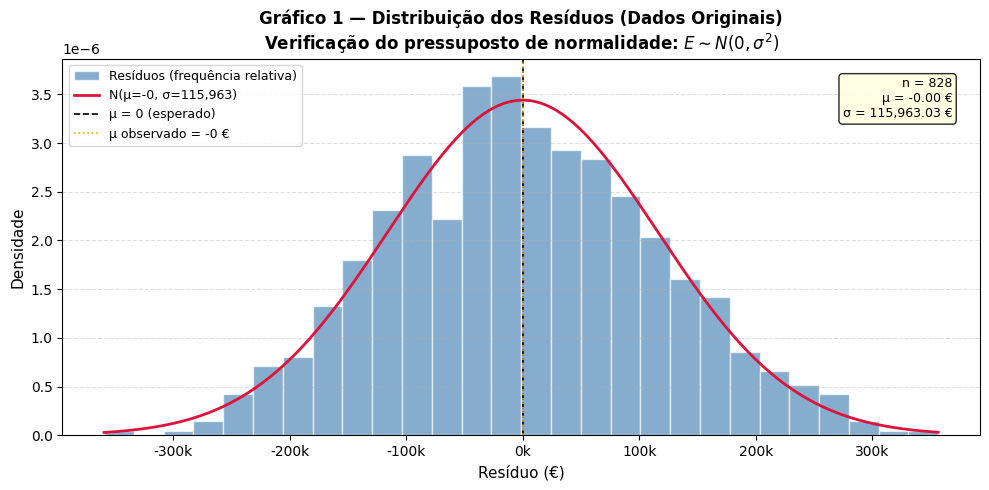

Gráfico guardado em: US30_histograma_residuos_originais.svg


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

# ── Histograma ──────────────────────────────────────────────────────────────
n_bins = int(np.sqrt(len(residuos_orig)))   # regra da raiz quadrada
counts, bins, _ = ax.hist(
    residuos_orig,
    bins=n_bins,
    density=True,
    color='steelblue', alpha=0.65, edgecolor='white',
    label='Resíduos (frequência relativa)'
)

# ── Curva normal sobreposta ─────────────────────────────────────────────────
mu_r  = residuos_orig.mean()
std_r = residuos_orig.std()
x_curva = np.linspace(residuos_orig.min(), residuos_orig.max(), 300)
ax.plot(
    x_curva,
    stats.norm.pdf(x_curva, mu_r, std_r),
    color='crimson', linewidth=2,
    label=f'N(μ={mu_r:,.0f}, σ={std_r:,.0f})'
)

# ── Linha μ = 0 ─────────────────────────────────────────────────────────────
ax.axvline(0,    color='black',  linewidth=1.2, linestyle='--', label='μ = 0 (esperado)')
ax.axvline(mu_r, color='orange', linewidth=1.2, linestyle=':',  label=f'μ observado = {mu_r:,.0f} €')

ax.set_xlabel('Resíduo (€)', fontsize=11)
ax.set_ylabel('Densidade', fontsize=11)
ax.set_title(
    'Gráfico 1 — Distribuição dos Resíduos (Dados Originais)\n'
    'Verificação do pressuposto de normalidade: $E \\sim N(0, \\sigma^2)$',
    fontsize=12, fontweight='bold'
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── Anotação estatísticas ────────────────────────────────────────────────────
ax.annotate(
    f'n = {len(residuos_orig)}\nμ = {mu_r:,.2f} €\nσ = {std_r:,.2f} €',
    xy=(0.97, 0.95), xycoords='axes fraction',
    fontsize=9, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.85)
)

plt.tight_layout()
plt.savefig('US30_histograma_residuos_originais.svg', format='svg', bbox_inches='tight')
plt.show()
print('Gráfico guardado em: US30_histograma_residuos_originais.svg')

## 4. Gráfico 2 — Histograma dos Resíduos (Dados Normalizados)

Após normalização z-score, os resíduos devem igualmente seguir uma distribuição normal centrada em zero, independentemente da escala original.

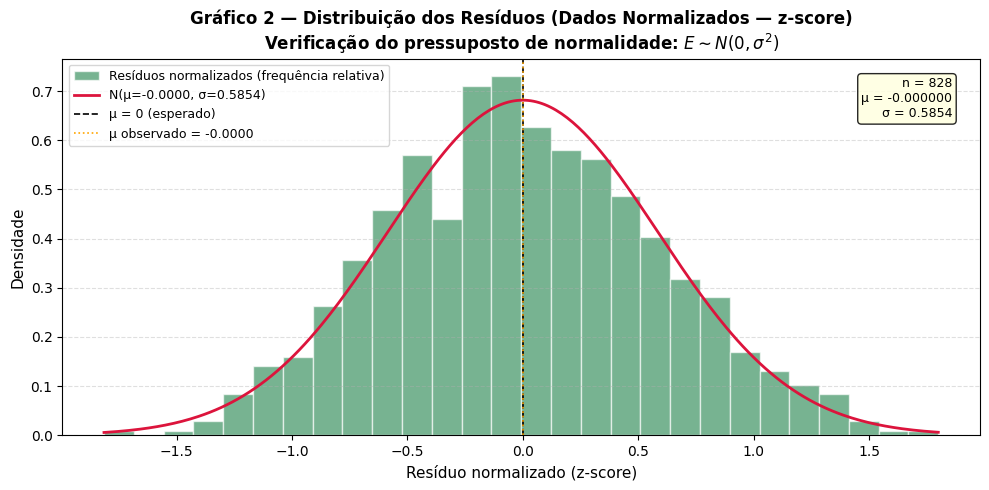

Gráfico guardado em: US30_histograma_residuos_normalizados.svg


In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

# ── Histograma ──────────────────────────────────────────────────────────────
n_bins_n = int(np.sqrt(len(residuos_norm)))
ax.hist(
    residuos_norm,
    bins=n_bins_n,
    density=True,
    color='seagreen', alpha=0.65, edgecolor='white',
    label='Resíduos normalizados (frequência relativa)'
)

# ── Curva normal sobreposta ─────────────────────────────────────────────────
mu_rn  = residuos_norm.mean()
std_rn = residuos_norm.std()
x_curva_n = np.linspace(residuos_norm.min(), residuos_norm.max(), 300)
ax.plot(
    x_curva_n,
    stats.norm.pdf(x_curva_n, mu_rn, std_rn),
    color='crimson', linewidth=2,
    label=f'N(μ={mu_rn:.4f}, σ={std_rn:.4f})'
)

# ── Linha μ = 0 ─────────────────────────────────────────────────────────────
ax.axvline(0,     color='black',  linewidth=1.2, linestyle='--', label='μ = 0 (esperado)')
ax.axvline(mu_rn, color='orange', linewidth=1.2, linestyle=':',  label=f'μ observado = {mu_rn:.4f}')

ax.set_xlabel('Resíduo normalizado (z-score)', fontsize=11)
ax.set_ylabel('Densidade', fontsize=11)
ax.set_title(
    'Gráfico 2 — Distribuição dos Resíduos (Dados Normalizados — z-score)\n'
    'Verificação do pressuposto de normalidade: $E \\sim N(0, \\sigma^2)$',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── Anotação estatísticas ────────────────────────────────────────────────────
ax.annotate(
    f'n = {len(residuos_norm)}\nμ = {mu_rn:.6f}\nσ = {std_rn:.4f}',
    xy=(0.97, 0.95), xycoords='axes fraction',
    fontsize=9, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.85)
)

plt.tight_layout()
plt.savefig('US30_histograma_residuos_normalizados.svg', format='svg', bbox_inches='tight')
plt.show()
print('Gráfico guardado em: US30_histograma_residuos_normalizados.svg')

## 5. Interpretação dos Resultados

In [19]:
print('=' * 70)
print('INTERPRETAÇÃO — US30')
print('=' * 70)
print(f"""
PRESSUPOSTO VERIFICADO: E ~ N(0, σ²)

DADOS ORIGINAIS
  Média dos resíduos  : {residuos_orig.mean():,.4f} €  (esperado = 0)
  Desvio padrão       : {residuos_orig.std():,.2f} €
  → A média dos resíduos é {'próxima de zero' if abs(residuos_orig.mean()) < residuos_orig.std() * 0.01 else 'não nula — verificar pressupostos'}.

DADOS NORMALIZADOS (z-score)
  Média dos resíduos  : {residuos_norm.mean():.6f}  (esperado = 0)
  Desvio padrão       : {residuos_norm.std():.4f}
  → Após normalização, a escala é removida e a forma da distribuição
    dos resíduos pode ser comparada diretamente com N(0,1).

CONCLUSÃO
  Se ambos os histogramas apresentam uma forma aproximadamente
  simétrica e centrada em zero, com a curva normal a ajustar-se bem,
  o pressuposto de normalidade dos erros é compatível com os dados,
  validando os resultados da regressão linear obtidos na US29.
  Caso contrário, os resultados devem ser interpretados com cautela.
""")

INTERPRETAÇÃO — US30

PRESSUPOSTO VERIFICADO: E ~ N(0, σ²)

DADOS ORIGINAIS
  Média dos resíduos  : -0.0000 €  (esperado = 0)
  Desvio padrão       : 115,963.03 €
  → A média dos resíduos é próxima de zero.

DADOS NORMALIZADOS (z-score)
  Média dos resíduos  : -0.000000  (esperado = 0)
  Desvio padrão       : 0.5854
  → Após normalização, a escala é removida e a forma da distribuição
    dos resíduos pode ser comparada diretamente com N(0,1).

CONCLUSÃO
  Se ambos os histogramas apresentam uma forma aproximadamente
  simétrica e centrada em zero, com a curva normal a ajustar-se bem,
  o pressuposto de normalidade dos erros é compatível com os dados,
  validando os resultados da regressão linear obtidos na US29.
  Caso contrário, os resultados devem ser interpretados com cautela.



# US31 — Deteção de Padrões Não-Lineares no Comportamento Financeiro

**Descrição:**  
Como membro do Comité de Ética, pretendo investigar se existem padrões não-lineares no comportamento financeiro, uma vez que algumas relações podem não seguir um padrão linear simples e podem revelar irregularidades mais subtis. Quero saber se a relação entre a percentagem de participação em empresas e o valor total declarado das ações segue um padrão constante ou se apresenta curvatura ou aceleração a níveis de participação mais elevados. Para cada par agente/empresa, considera-se apenas a declaração mais recente.

---

## Conceitos Teóricos Aplicados

### Variáveis
- **Variável independente** ($x$): `company_percentage` — percentagem de participação do agente na empresa;
- **Variável dependente** ($y$): `total_value_in_stocks` — valor total declarado das ações.

### Modelo Linear (Grau 1)
O modelo de regressão linear simples relaciona as duas variáveis através de uma reta:

$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x$$

As estimativas dos mínimos quadrados são:

$$\hat{\beta}_1 = \frac{S_{xy}}{S_{xx}}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

### Modelo Quadrático (Grau 2)
O modelo de regressão polinomial de grau 2 introduz um termo quadrático que permite capturar curvatura na relação:

$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x + \hat{\beta}_2 x^2$$

O coeficiente $\hat{\beta}_2$ indica:
- $\hat{\beta}_2 > 0$ — curvatura **côncava** (aceleração crescente — crescimento disproportionado a níveis elevados de participação);
- $\hat{\beta}_2 < 0$ — curvatura **convexa** (desaceleração — crescimento que abranda a níveis elevados);
- $\hat{\beta}_2 \approx 0$ — relação essencialmente **linear**.

### Coeficiente de Determinação $r^2$
O $r^2$ mede a proporção da variabilidade total de $y$ explicada pelo modelo:

$$r^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2} = 1 - \frac{SQE}{S_{yy}}$$

Um $r^2$ significativamente superior no modelo quadrático face ao linear indica a presença de curvatura relevante na relação.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── Carregamento e limpeza ──────────────────────────────────────────────────
df = pd.read_csv('../Dados/Regression_dataset2_holdings.csv')
df.columns = df.columns.str.strip()
df['declaration_date'] = pd.to_datetime(df['declaration_date'])

print(f"Dataset carregado: {df.shape[0]} registos")
print(f"Agentes únicos   : {df['agent_id'].nunique()}")
print(f"Empresas únicas  : {df['company_NIF'].nunique()}")
print(f"Pares únicos (agente, empresa): {df.groupby(['agent_id', 'company_NIF']).ngroups}")

Dataset carregado: 498 registos
Agentes únicos   : 195
Empresas únicas  : 186
Pares únicos (agente, empresa): 493


## 1. Seleção da Declaração Mais Recente por Par Agente/Empresa

Para cada par (`agent_id`, `company_NIF`), considera-se apenas o registo com a data mais recente.

In [21]:
# ── Declaração mais recente por par (agent_id, company_NIF) ─────────────────
idx_last = df.groupby(['agent_id', 'company_NIF'])['declaration_date'].idxmax()
df_last  = df.loc[idx_last].reset_index(drop=True)

print(f"Pares agente/empresa considerados (declaração mais recente): {len(df_last)}")
print(f"\nEstatísticas descritivas:")
print(df_last[['company_percentage', 'total_value_in_stocks']].describe().round(2).to_string())

Pares agente/empresa considerados (declaração mais recente): 493

Estatísticas descritivas:
       company_percentage  total_value_in_stocks
count              493.00                 493.00
mean                29.49              102903.33
std                 17.19              167270.75
min                  0.14                   0.00
25%                 14.33                   0.00
50%                 28.48                9008.01
75%                 44.16              144399.06
max                 59.96              926024.69


## 2. Modelo Linear — Estimação Manual

Estimamos o modelo linear pelo método dos mínimos quadrados, calculando manualmente $S_{xx}$, $S_{yy}$ e $S_{xy}$.

In [22]:
x = df_last['company_percentage'].values
y = df_last['total_value_in_stocks'].values

# ── Mínimos quadrados manual — modelo linear ────────────────────────────────
x_bar = x.mean()
y_bar = y.mean()
Sxx   = np.sum((x - x_bar) ** 2)
Syy   = np.sum((y - y_bar) ** 2)
Sxy   = np.sum((x - x_bar) * (y - y_bar))

beta1_lin = Sxy / Sxx
beta0_lin = y_bar - beta1_lin * x_bar

y_hat_lin    = beta0_lin + beta1_lin * x
sqe_lin      = np.sum((y - y_hat_lin) ** 2)
r2_lin       = 1 - sqe_lin / Syy
r_lin        = Sxy / np.sqrt(Sxx * Syy)

print('MODELO LINEAR')
print(f'  Reta: total_value_in_stocks = {beta0_lin:,.2f} + {beta1_lin:.4f} × company_percentage')
print(f'  r   = {r_lin:.4f}')
print(f'  r²  = {r2_lin:.4f}  → explica {r2_lin*100:.1f}% da variabilidade total')
print(f'  sqe = {sqe_lin:,.2f}')

MODELO LINEAR
  Reta: total_value_in_stocks = 102,936.64 + -1.1294 × company_percentage
  r   = -0.0001
  r²  = 0.0000  → explica 0.0% da variabilidade total
  sqe = 13,765,916,285,875.80


## 3. Modelo Quadrático — Estimação

O modelo quadrático $\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x + \hat{\beta}_2 x^2$ é estimado recorrendo a `numpy.polyfit` de grau 2, uma vez que a estimação manual dos três coeficientes simultaneamente requer álgebra matricial. O $r^2$ é calculado manualmente a partir dos resíduos.

In [23]:
# ── Modelo quadrático via numpy.polyfit (grau 2) ────────────────────────────
coefs_quad = np.polyfit(x, y, 2)          # [β̂₂, β̂₁, β̂₀]
beta2_quad = coefs_quad[0]
beta1_quad = coefs_quad[1]
beta0_quad = coefs_quad[2]

y_hat_quad = beta0_quad + beta1_quad * x + beta2_quad * (x ** 2)

# ── r² calculado manualmente ────────────────────────────────────────────────
sqe_quad = np.sum((y - y_hat_quad) ** 2)
r2_quad  = 1 - sqe_quad / Syy

# ── Sinal de β̂₂ ─────────────────────────────────────────────────────────────
if abs(beta2_quad) < 1e-6:
    tipo_curvatura = 'praticamente nulo — relação essencialmente linear'
elif beta2_quad > 0:
    tipo_curvatura = 'positivo — curvatura côncava (aceleração crescente)'
else:
    tipo_curvatura = 'negativo — curvatura convexa (desaceleração)'

print('MODELO QUADRÁTICO')
print(f'  Curva: ŷ = {beta0_quad:,.2f} + {beta1_quad:.4f}x + {beta2_quad:.4f}x²')
print(f'  β̂₂ = {beta2_quad:.4f}  → {tipo_curvatura}')
print(f'  r²  = {r2_quad:.4f}  → explica {r2_quad*100:.1f}% da variabilidade total')
print(f'  sqe = {sqe_quad:,.2f}')

# ── Ganho de r² ─────────────────────────────────────────────────────────────
ganho_r2 = r2_quad - r2_lin
print(f'\n  Ganho de r² (quadrático vs. linear): {ganho_r2:+.4f} ({ganho_r2*100:+.2f}%)')

MODELO QUADRÁTICO
  Curva: ŷ = 126,167.38 + -2357.4282x + 39.7201x²
  β̂₂ = 39.7201  → positivo — curvatura côncava (aceleração crescente)
  r²  = 0.0040  → explica 0.4% da variabilidade total
  sqe = 13,711,098,937,690.57

  Ganho de r² (quadrático vs. linear): +0.0040 (+0.40%)


## 4. Comparação dos Modelos

In [24]:
print('=' * 70)
print('COMPARAÇÃO — MODELO LINEAR vs. QUADRÁTICO')
print('=' * 70)
print(f"{'Métrica':<30} {'Linear':>15} {'Quadrático':>15}")
print('-' * 62)
print(f"{'Equação':<30} {'ŷ=β₀+β₁x':>15} {'ŷ=β₀+β₁x+β₂x²':>15}")
print(f"{'β̂₀ (intercepto)':<30} {beta0_lin:>15,.2f} {beta0_quad:>15,.2f}")
print(f"{'β̂₁ (declive linear)':<30} {beta1_lin:>15.4f} {beta1_quad:>15.4f}")
print(f"{'β̂₂ (curvatura)':<30} {'—':>15} {beta2_quad:>15.4f}")
print(f"{'r² (coef. determinação)':<30} {r2_lin:>15.4f} {r2_quad:>15.4f}")
print(f"{'SQE (soma quad. resíduos)':<30} {sqe_lin:>15,.2f} {sqe_quad:>15,.2f}")
print(f"{'Ganho r²':<30} {'—':>15} {ganho_r2:>+15.4f}")

COMPARAÇÃO — MODELO LINEAR vs. QUADRÁTICO
Métrica                                 Linear      Quadrático
--------------------------------------------------------------
Equação                               ŷ=β₀+β₁x   ŷ=β₀+β₁x+β₂x²
β̂₀ (intercepto)                    102,936.64      126,167.38
β̂₁ (declive linear)                   -1.1294      -2357.4282
β̂₂ (curvatura)                              —         39.7201
r² (coef. determinação)                 0.0000          0.0040
SQE (soma quad. resíduos)      13,765,916,285,875.80 13,711,098,937,690.57
Ganho r²                                     —         +0.0040


## 5. Visualização — Dispersão com Modelo Linear e Quadrático

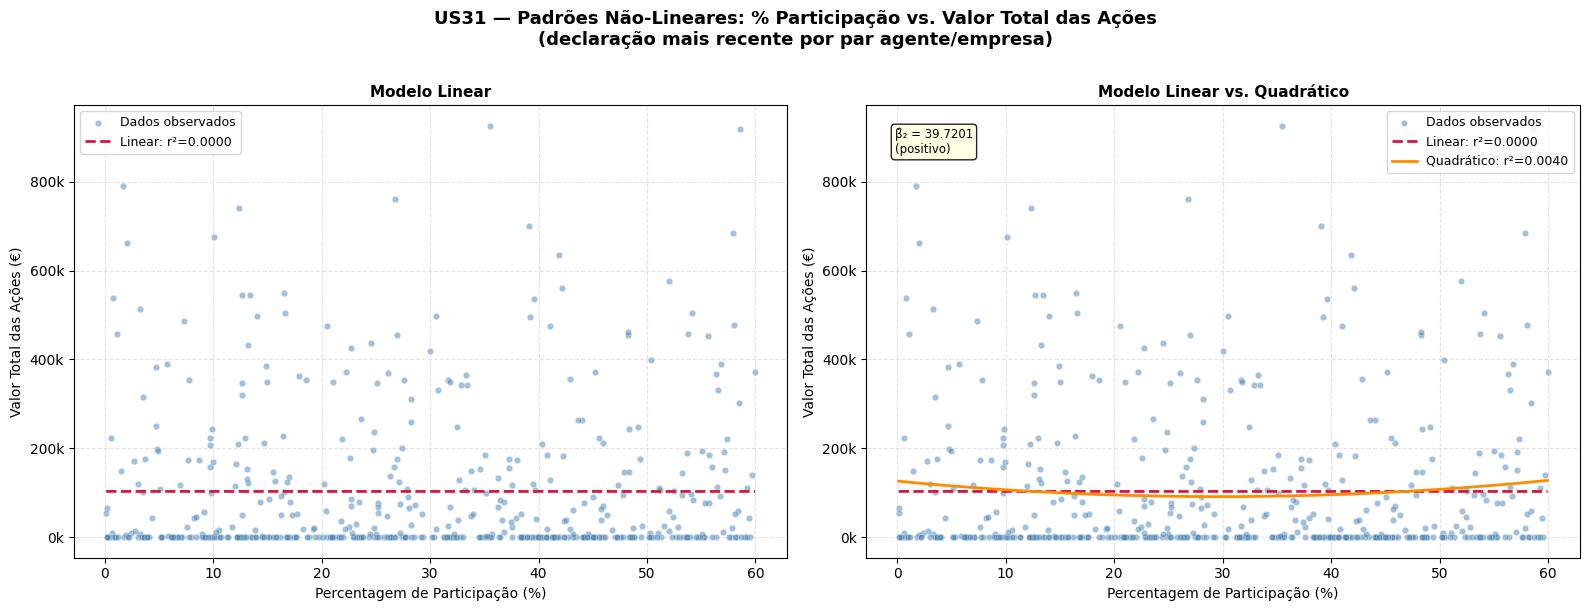

Gráfico guardado em: US31_linear_vs_quadratico.svg


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'US31 — Padrões Não-Lineares: % Participação vs. Valor Total das Ações\n'
    '(declaração mais recente por par agente/empresa)',
    fontsize=13, fontweight='bold', y=1.01
)

x_line = np.linspace(x.min(), x.max(), 300)

for ax, mostrar_quad in zip(axes, [False, True]):
    # Dispersão
    ax.scatter(
        x, y,
        color='steelblue', alpha=0.5, s=22,
        edgecolors='white', linewidths=0.4,
        label='Dados observados'
    )

    # Modelo linear
    ax.plot(
        x_line, beta0_lin + beta1_lin * x_line,
        color='crimson', linewidth=2, linestyle='--',
        label=f'Linear: r²={r2_lin:.4f}'
    )

    if mostrar_quad:
        # Modelo quadrático
        y_quad_line = beta0_quad + beta1_quad * x_line + beta2_quad * (x_line ** 2)
        ax.plot(
            x_line, y_quad_line,
            color='darkorange', linewidth=2, linestyle='-',
            label=f'Quadrático: r²={r2_quad:.4f}'
        )
        ax.set_title(
            'Modelo Linear vs. Quadrático',
            fontsize=11, fontweight='bold'
        )
    else:
        ax.set_title(
            'Modelo Linear',
            fontsize=11, fontweight='bold'
        )

    # Anotação β̂₂ no gráfico quadrático
    if mostrar_quad:
        ax.annotate(
            f'β̂₂ = {beta2_quad:.4f}\n({tipo_curvatura.split("—")[0].strip()})',
            xy=(0.04, 0.95), xycoords='axes fraction',
            fontsize=8.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.85)
        )

    ax.set_xlabel('Percentagem de Participação (%)', fontsize=10)
    ax.set_ylabel('Valor Total das Ações (€)', fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
    ax.legend(fontsize=9)
    ax.grid(linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('US31_linear_vs_quadratico.svg', format='svg', bbox_inches='tight')
plt.show()
print('Gráfico guardado em: US31_linear_vs_quadratico.svg')

## 6. Interpretação dos Resultados

In [26]:
LIMIAR_GANHO = 0.02    # ganho mínimo de r² para considerar o modelo quadrático relevante

print('=' * 70)
print('INTERPRETAÇÃO — US31')
print('=' * 70)
print(f"""
MODELO LINEAR
  ŷ = {beta0_lin:,.2f} + {beta1_lin:.4f} × company_percentage
  r² = {r2_lin:.4f} → explica {r2_lin*100:.1f}% da variabilidade do valor das ações.

MODELO QUADRÁTICO
  ŷ = {beta0_quad:,.2f} + {beta1_quad:.4f}x + {beta2_quad:.4f}x²
  r² = {r2_quad:.4f} → explica {r2_quad*100:.1f}% da variabilidade do valor das ações.
  β̂₂ = {beta2_quad:.4f} → {tipo_curvatura}

CONCLUSÃO""")

if ganho_r2 >= LIMIAR_GANHO:
    print(f"""  O modelo quadrático apresenta um ganho de r² de {ganho_r2:.4f} face ao linear.
  Este ganho é relevante, sugerindo que a relação entre a percentagem
  de participação e o valor das ações NÃO segue um padrão linear simples.
  Existe evidência de {'aceleração crescente (concentração de risco a níveis elevados de participação)' if beta2_quad > 0 else 'desaceleração (crescimento que abranda a participações elevadas)'}.
  Este padrão pode sinalizar exposição financeira desproporcional.""")
else:
    print(f"""  O ganho de r² do modelo quadrático face ao linear é de apenas {ganho_r2:.4f},
  considerado pouco relevante (limiar: {LIMIAR_GANHO}).
  Não há evidência suficiente de curvatura significativa na relação.
  O modelo linear descreve adequadamente o padrão observado nos dados.""")

INTERPRETAÇÃO — US31

MODELO LINEAR
  ŷ = 102,936.64 + -1.1294 × company_percentage
  r² = 0.0000 → explica 0.0% da variabilidade do valor das ações.

MODELO QUADRÁTICO
  ŷ = 126,167.38 + -2357.4282x + 39.7201x²
  r² = 0.0040 → explica 0.4% da variabilidade do valor das ações.
  β̂₂ = 39.7201 → positivo — curvatura côncava (aceleração crescente)

CONCLUSÃO
  O ganho de r² do modelo quadrático face ao linear é de apenas 0.0040,
  considerado pouco relevante (limiar: 0.02).
  Não há evidência suficiente de curvatura significativa na relação.
  O modelo linear descreve adequadamente o padrão observado nos dados.
